# **Impact of an emergency situation on housing and the availability of temporary accommodation in California counties.**

Name: Diana Valverde

# **ORDER**

1. Data Cleaning
2. Questions

*   Question 1 + Graph
*   Question 2 + Graph
*   Question 3 + Graph

3. Conclusions

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving housing-impact-data-file-odp-4.csv to housing-impact-data-file-odp-4.csv


In [3]:
with open("housing-impact-data-file-odp-4.csv", "r", encoding="cp1252") as file:
    for i, line in enumerate(file):
        if 34 <= i <= 42:
            print(i + 1, repr(line))

35 '\x004\x00/\x001\x004\x00/\x002\x000\x002\x000\x00\t\x00L\x00a\x00k\x00e\x00 \x00C\x00o\x00u\x00n\x00t\x00y\x00\t\x00\t\x00\t\x00\t\x00\t\x00\n'
36 '\x00\n'
37 '\x004\x00/\x001\x004\x00/\x002\x000\x002\x000\x00\t\x00L\x00a\x00s\x00s\x00e\x00n\x00 \x00C\x00o\x00u\x00n\x00t\x00y\x00\t\x00\t\x00\t\x00\t\x00\t\x00\n'
38 '\x00\n'
39 '\x004\x00/\x001\x004\x00/\x002\x000\x002\x000\x00\t\x00L\x00o\x00s\x00 \x00A\x00n\x00g\x00e\x00l\x00e\x00s\x00 \x00C\x00o\x00u\x00n\x00t\x00y\x00\t\x002\x00,\x006\x005\x004\x00\t\x005\x003\x005\x00\t\x006\x005\x008\x00\t\x006\x005\x004\x00\t\x00\n'
40 '\x00\n'
41 '\x004\x00/\x001\x004\x00/\x002\x000\x002\x000\x00\t\x00M\x00a\x00d\x00e\x00r\x00a\x00 \x00C\x00o\x00u\x00n\x00t\x00y\x00\t\x00\t\x00\t\x00\t\x00\t\x00\n'
42 '\x00\n'
43 '\x004\x00/\x001\x004\x00/\x002\x000\x002\x000\x00\t\x00M\x00a\x00r\x00i\x00n\x00 \x00C\x00o\x00u\x00n\x00t\x00y\x00\t\x008\x000\x00\t\x004\x003\x00\t\x004\x004\x00\t\x00\t\x00\n'


In [4]:
import pandas as pd

df = pd.read_csv(
    "housing-impact-data-file-odp-4.csv",
    encoding="utf-16",
    sep="\t"
)

df.head()

,Date,County,Rooms,Rooms Occupied,Trailers Requested,Trailers Delivered,Donated Trailers Delivered
0,4/14/2020,Alameda County,403,115,91.0,85.0,NaN
1,4/14/2020,Alpine County,NaN,NaN,NaN,NaN,NaN
2,4/14/2020,Amador County,NaN,NaN,NaN,NaN,NaN
3,4/14/2020,Butte County,65,65,NaN,NaN,NaN
4,4/14/2020,Calaveras County,NaN,NaN,NaN,NaN,NaN


# **1. DATA CLEANING**

1.1. How much data we have?

In [5]:
df.shape
#22,739 rows
#7 columns

#I used df.shape to check the size od the dataset. It tells me how many rows and columns are incleded.


(22739, 7)

1.2. What kind of information we have.

In [6]:
df.info()
#object → generally text.
#int64 → integers.
#float64 → numbers with decimals.

#df.info() helps me to understand the structure od the dataset. It shows the column names, number of non-null values, and the data type of each variable.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22739 entries, 0 to 22738
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        22739 non-null  object 
 1   County                      22733 non-null  object 
 2   Rooms                       13965 non-null  object 
 3   Rooms Occupied              12340 non-null  object 
 4   Trailers Requested          7401 non-null   float64
 5   Trailers Delivered          5796 non-null   float64
 6   Donated Trailers Delivered  684 non-null    float64
dtypes: float64(3), object(4)
memory usage: 1.2+ MB


1.3. Check for missing values.

In [7]:
df.isnull().sum()

#helps me to check the number of missing values in each column using.

,0
Date,0
County,6
Rooms,8774
Rooms Occupied,10399
Trailers Requested,15338
Trailers Delivered,16943
Donated Trailers Delivered,22055


1.4. Search for duplicates

In [8]:
df.duplicated().sum()

#I checked whether the dataset contained duplicate rows. The result was zero, so no duplicate records needed to be removed

np.int64(0)

1.5. Set the date

In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype
#We do this so that Python can understand the months of the year, enabling us to create graphs for the future.
#I converted the Date column into a datetime format so Python could recognize it as an actual date and allow me to analyze changes over time.

dtype('<M8[ns]')

1.6. Review the counties

In [10]:
df["County"].nunique()

72

In [11]:
df["County"].unique()
#I reviewed the county variable to see how many different counties were represented and to inspect their names

array(['Alameda County', 'Alpine County', 'Amador County', 'Butte County',
       'Calaveras County', 'Colusa County', 'Contra Costa County',
       'Del Norte County', 'El Dorado County', 'Fresno County',
       'Glenn County', 'Humboldt County', 'Imperial County',
       'Inyo County', 'Kern County', 'Kings County', 'Lake County',
       'Lassen County', 'Los Angeles County', 'Madera County',
       'Marin County', 'Mariposa County', 'Mendocino County',
       'Merced County', 'Modoc County', 'Mono County', 'Monterey County',
       'Napa County', 'Nevada County', 'Orange County', 'Placer County',
       'Plumas County', 'Riverside County', 'Sacramento County',
       'San Benito County', 'San Bernardino County', 'San Diego County',
       'San Francisco County', 'San Joaquin County',
       'San Luis Obispo County', 'San Mateo County',
       'Santa Barbara County', 'Santa Clara County', 'Santa Cruz County',
       'Shasta County', 'Sierra County', 'Siskiyou County',
       'Solano 

1.7. Review missing County values

In [12]:
df[df["County"].isnull()]

#Only six records were missing county information. Because the county could not be identified from the other variables, I removed those six records.

,Date,County,Rooms,Rooms Occupied,Trailers Requested,Trailers Delivered,Donated Trailers Delivered
19280,2022-06-17,NaN,NaN,NaN,NaN,NaN,NaN
19529,2022-07-15,NaN,NaN,NaN,NaN,NaN,NaN
20152,2022-09-23,NaN,NaN,NaN,NaN,NaN,NaN
20594,2022-11-10,NaN,NaN,NaN,NaN,NaN,NaN
20721,2022-11-23,NaN,NaN,NaN,NaN,NaN,NaN
20911,2022-12-16,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df = df.dropna(subset=["County"])
df["County"].isnull().sum()

np.int64(0)

1.8. Clean County names

In [14]:
df["County"] = df["County"].str.strip()
df["County"].nunique()

##I removed extra spaces from county names to prevent the same county from being interpreted as two different categories.

72

In [15]:
df["County"].unique()

array(['Alameda County', 'Alpine County', 'Amador County', 'Butte County',
       'Calaveras County', 'Colusa County', 'Contra Costa County',
       'Del Norte County', 'El Dorado County', 'Fresno County',
       'Glenn County', 'Humboldt County', 'Imperial County',
       'Inyo County', 'Kern County', 'Kings County', 'Lake County',
       'Lassen County', 'Los Angeles County', 'Madera County',
       'Marin County', 'Mariposa County', 'Mendocino County',
       'Merced County', 'Modoc County', 'Mono County', 'Monterey County',
       'Napa County', 'Nevada County', 'Orange County', 'Placer County',
       'Plumas County', 'Riverside County', 'Sacramento County',
       'San Benito County', 'San Bernardino County', 'San Diego County',
       'San Francisco County', 'San Joaquin County',
       'San Luis Obispo County', 'San Mateo County',
       'Santa Barbara County', 'Santa Clara County', 'Santa Cruz County',
       'Shasta County', 'Sierra County', 'Siskiyou County',
       'Solano 

I removed unnecessary spaces from the county names to prevent the same county from being interpreted as different categories.

1.9. Convert Rooms to numeric

In [16]:
#code for rooms
#converting Rooms & Rooms Occupied from text to numeric.

df["Rooms"] = (
    df["Rooms"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Rooms"] = pd.to_numeric(
    df["Rooms"],
    errors="coerce"
)

In [17]:
#code for occupied

df["Rooms Occupied"] = (
    df["Rooms Occupied"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Rooms Occupied"] = pd.to_numeric(
    df["Rooms Occupied"],
    errors="coerce"
)

The variables Rooms and Rooms Occupied were imported as text because some values contain commas. I removed the commas and converted these columns into numeric variables so they could be used for calculations and statistical analysis.

1.10. Check the data types again

In [18]:
df.info()

#After converting the room variables, I checked the data types again to confirm that the conversion was successful.

<class 'pandas.core.frame.DataFrame'>
Index: 22733 entries, 0 to 22738
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        22733 non-null  datetime64[ns]
 1   County                      22733 non-null  object        
 2   Rooms                       13965 non-null  float64       
 3   Rooms Occupied              12340 non-null  float64       
 4   Trailers Requested          7401 non-null   float64       
 5   Trailers Delivered          5796 non-null   float64       
 6   Donated Trailers Delivered  684 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 1.4+ MB


After converting the room variables, I checked the data types again to confirm that all housing variables were stored as numeric values.

1.11. Check missing values again

In [19]:
#Missing Values again after cleaning the county variable and converting the numeric columns.
df.isnull().sum()

,0
Date,0
County,0
Rooms,8768
Rooms Occupied,10393
Trailers Requested,15332
Trailers Delivered,16937
Donated Trailers Delivered,22049


Confirms that the previous cleaning worked. We removed the 6 rows where "County" was empty. Those same 6 rows also had missing values ​​in the other columns, so deleting them reduced the NaN count by 6 as well.

1.12. Percentage of missing values

In [20]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_data

#calculated both the number and percentage of missing values because the percentage makes it easier to understand how serious the missing-data problem is.

,Missing Values,Missing Percentage
Date,0,0.00
County,0,0.00
Rooms,8768,38.57
Rooms Occupied,10393,45.72
Trailers Requested,15332,67.44
Trailers Delivered,16937,74.50
Donated Trailers Delivered,22049,96.99


After removing the records with missing county information, I calculated the percentage of missing values for each variable.
Some housing variables contain a large amount of missing data, especially the trailer-related variables. I decided not to automatically replace these values with zero because a missing value may mean that the information was not reported rather than that no housing assistance was provided.

1.13. Review negative numbers

In [21]:
#I checked the numeric variables for negative values because negative numbers would not make sense for counts of rooms or trailers

numeric_columns = [
    "Rooms",
    "Rooms Occupied",
    "Trailers Requested",
    "Trailers Delivered",
    "Donated Trailers Delivered"
]

for column in numeric_columns:
    print(column, ":", (df[column] < 0).sum())

Rooms : 0
Rooms Occupied : 0
Trailers Requested : 0
Trailers Delivered : 0
Donated Trailers Delivered : 0


In [22]:
df[
    [
        "Rooms",
        "Rooms Occupied",
        "Trailers Requested",
        "Trailers Delivered",
        "Donated Trailers Delivered"
    ]
].describe()

#I used descriptive statistics to summarize the numerical variables and understand their typical values, spread, minimum, and maximum.

,Rooms,Rooms Occupied,Trailers Requested,Trailers Delivered,Donated Trailers Delivered
count,13965.000000,12340.000000,7401.000000,5796.000000,684.000000
mean,332.417615,244.529822,77.703148,80.101967,16.415205
std,694.840836,498.116449,136.468504,153.183972,4.082976
min,11.000000,11.000000,12.000000,12.000000,12.000000
25%,48.000000,37.000000,15.000000,15.000000,12.000000
50%,111.000000,82.000000,37.000000,28.000000,20.000000
75%,273.000000,233.000000,91.000000,79.000000,20.000000
max,4697.000000,3942.000000,658.000000,654.000000,40.000000


1.14. Check if Rooms Occupied is greater than Rooms

In [23]:
#I checked whether any records reported more occupied rooms than available rooms

rooms_problem = df[df["Rooms Occupied"] > df["Rooms"]]

print("Inconsistent records:", len(rooms_problem))
print("Percentage:", round(len(rooms_problem) / len(df) * 100, 2), "%")

Inconsistent records: 50
Percentage: 0.22 %


I found 50 potentially inconsistent observations. Because they represent a very small proportion of the dataset, I identified them instead of deleting the entire dataset or making assumptions about their cause.

1.15. Check if Trailers Delivered is greater than Requested

In [25]:
(df["Trailers Delivered"] > df["Trailers Requested"]).sum()

#I checked whether more trailers were delivered than requested. No records showed this inconsistency.

np.int64(0)

1.16. Reset the index

Since we removed 6 records from County, the following step simply reorders the row numbers.

In [53]:
df = df.reset_index(drop=True)
#After removing records, I reset the index so the row numbers were sequential again.

1.17. Final cleaning check

After cleaning the dataset, I performed a final check of its size, duplicates, missing values, and data types.

In [54]:
print("Dataset shape:")
print(df.shape)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

#we could still see missing values NaN but that is ok.

Dataset shape:
(22733, 7)

Duplicate rows:
0

Missing values:
Date                              0
County                            0
Rooms                          8768
Rooms Occupied                10393
Trailers Requested            15332
Trailers Delivered            16937
Donated Trailers Delivered    22049
dtype: int64

Data types:
Date                          datetime64[ns]
County                                object
Rooms                                float64
Rooms Occupied                       float64
Trailers Requested                   float64
Trailers Delivered                   float64
Donated Trailers Delivered           float64
dtype: object


1.18. Final CLEAN Dataset

In [31]:
clean_df = df.copy()
#I created a copy called clean_df so the analysis would be performed using the cleaned version of the dataset.

1.19. Create only the new variables we will actually use; we will create only variables that answer real questions.

*1.19.1. YEAR*

In [27]:
clean_df["Year"] = clean_df["Date"].dt.year
#I extracted the year from the Date column because the first research question analyzes changes over time

*1.19.2. Room Occupancy Rate*

In [67]:
valid_rooms = (
    clean_df["Rooms"].notna() &
    clean_df["Rooms Occupied"].notna() &
    (clean_df["Rooms"] > 0) &
    (clean_df["Rooms Occupied"] <= clean_df["Rooms"])
)

In [68]:
clean_df.loc[
    valid_rooms,
    "Room Occupancy Rate"
] = (
    clean_df.loc[valid_rooms, "Rooms Occupied"] /
    clean_df.loc[valid_rooms, "Rooms"]
) * 100

# **2. QUESTIONS**

**2.1. Question 1**

How has the use of emergency housing rooms changed over time?




In [33]:
#I grouped the data by year and calculated the total number of occupied rooms for each year. A line chart is appropiate because I am analyzing change over time.
q1 = (
    clean_df.groupby("Year")["Rooms Occupied"]
    .sum()
    .reset_index()
)

KeyError: 'Year'

In [32]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=q1,
    x="Year",
    y="Rooms Occupied",
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.title("Emergency Housing Assistance Over Time")
plt.xlabel("Year")
plt.ylabel("Total Rooms Occupied")
plt.grid(alpha=0.3)

plt.show()

NameError: name 'q1' is not defined

<Figure size 1000x500 with 0 Axes>

This graph shows how the total number of occupied emergency housing rooms changed over time.

**2.2. Question 2**

Which counties had the highest number of occupied emergency housing rooms?

We are going to use the 10 counties with the most occupied rooms. I grouped the records by county, summed the occupied rooms, ranked the counties from highest to lowest, and selected the top ten. I used a bar chart because it makes it easy to compare the total values across counties.

In [29]:
q2 = (
    clean_df.groupby("County")["Rooms Occupied"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

<Axes: xlabel='Rooms Occupied', ylabel='County'>

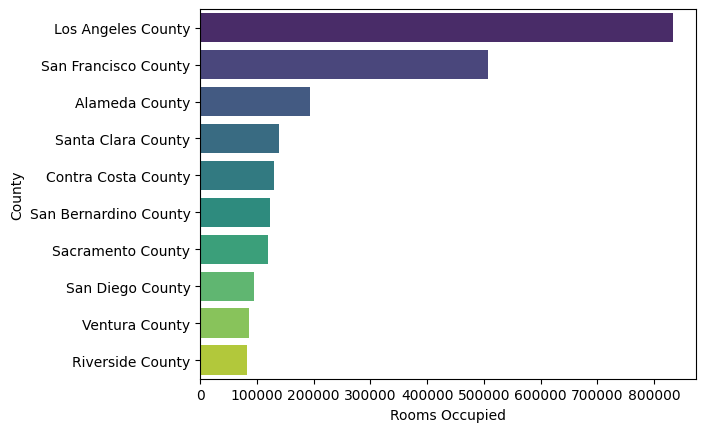

In [30]:
sns.barplot(
    data=q2,
    x="Rooms Occupied",
    y="County",
    hue="County",
    palette="viridis",
    legend=False
)

This graph identifies the counties that received the highest amount of emergency housing assistance.

**2.3. Question 3**

How closely did trailer deliveries meet trailer requests?


For this question, I only used records where both Trailers Requested and Trailers Delivered were available. I did not replace missing values with zero.

In [82]:
trailers = clean_df.dropna(
    subset=["Trailers Requested", "Trailers Delivered"]
).copy()

In [83]:
trailers["Trailer Gap"] = (
    trailers["Trailers Requested"] -
    trailers["Trailers Delivered"]
)

In [84]:
q3 = (
    trailers.groupby("Year")[
        ["Trailers Requested", "Trailers Delivered"]
    ]
    .sum()
    .reset_index()
)

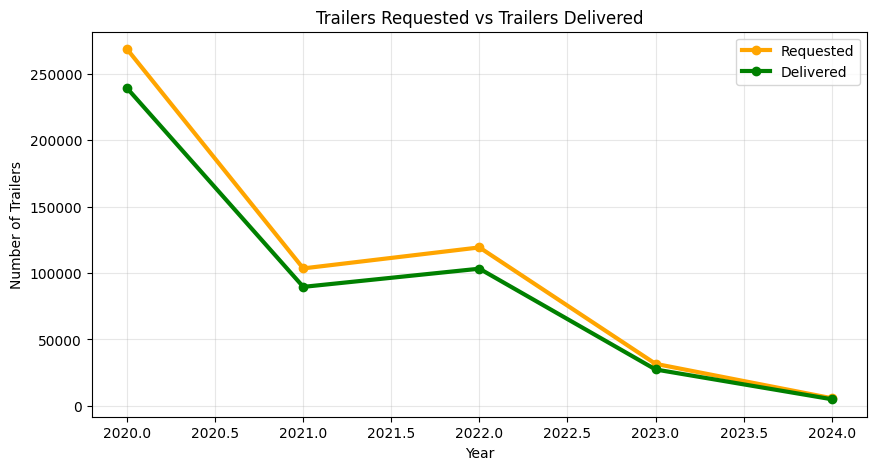

In [85]:
plt.figure(figsize=(10,5))

plt.plot(
    q3["Year"],
    q3["Trailers Requested"],
    marker="o",
    linewidth=3,
    label="Requested",
    color="orange"
)

plt.plot(
    q3["Year"],
    q3["Trailers Delivered"],
    marker="o",
    linewidth=3,
    label="Delivered",
    color="green"
)

plt.title("Trailers Requested vs Trailers Delivered")
plt.xlabel("Year")
plt.ylabel("Number of Trailers")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The closer the two lines are, the more closely deliveries matched requests. A larger distance between the lines indicates a larger gap between demand and delivery.

# **3. CONCLUSIONES**

- Emergency housing rooms over time

The use of emergency housing rooms decreased substantially from 2020 to 2024. The highest level of occupied rooms was recorded in 2020, followed by a continuous decline in the following years. By 2024, the number of occupied rooms was much lower than at the beginning of the period.

- Counties with the highest use

Los Angeles County had the highest total number of occupied emergency housing rooms among the counties in the dataset. San Francisco County ranked second, while the remaining counties had considerably lower totals. This shows that emergency housing room use was not evenly distributed across counties.

- Trailers requested vs delivered

Trailer deliveries generally followed the same pattern as trailer requests. In every year shown, the number of trailers delivered was lower than the number requested. The gap was larger in the earlier years and became smaller toward 2023 and 2024.

My dataset contains many missing values. I kept them as NaN because missing does not necessarily mean zero. Removing every row with missing data would also remove a large amount of useful information. Therefore, for each research question, I used only the observations containing the variables required for that specific analysis.

The dataset contained a significant amount of missing information. Instead of replacing missing values with zero or deleting all incomplete records, the analysis used the available observations required for each research question. This helped preserve useful data while avoiding unsupported assumptions.